# Plots

## Libraries and collected data

For how the rates were determined, see below.

In [3]:
library(ggplot2)
# library(fillpattern)
library(dplyr)
library(readxl)
library(tidyr)
library(stringr)

fig_size = function(width, heigth){
    options(repr.plot.width = width, repr.plot.height = heigth)
}

color_key = list(
    'human' = 'firebrick4',
    'pig' = 'navyblue',
    'cattle' = 'purple4'
)

human_tissue_n = c(515, 396, 305, 208, 233, 73, 469, 174, 167, 129, 517, 141, 605, 483, 581, 706, 144, 574, 387, 372, 213, 386, 497, 465, 330, 227, 324, 368, 318, 221, 322, 670, 147, 584, 532, 175, 147, 194, 202, 170, 170, 129, 165, 114, 209, 175, 126, 237)
# barbeira_tissue_n = pividori_tissue_n
pig_tissue_n = c(75, 50, 48, 88, 1321, 164, 285, 501, 91, 63, 44, 270, 75, 49, 128, 68, 67, 65, 419, 73, 53, 386, 84, 59, 149, 536, 56, 76, 150, 213, 61, 204, 98, 184)
cattle_tissue_n = c(699, 698, 576, 359, 295, 281, 202, 175, 173, 160, 151, 139, 134, 113, 112, 105, 87, 87, 85, 63, 60, 43, 41, 40)
# human_tissue_n = c(581, 469, 233, 387, 213, 584, 129, 147, 194, 175, 209, 205, 175, 165, 170, 202, 170, 126, 114, 396, 147, 483, 318, 368, 330, 497, 465, 372, 386, 73, 208, 515, 144, 706, 532, 167, 305, 237, 221, 517, 605, 174, 227, 324, 322, 574, 129, 141, 670)

studies = factor(
    c('Pividori et al. 2020', 'Barbeira et al. 2021', 'Barbeira et al. 2021 (no blood)', 'Hukku et al. 2022', 'Hukku et al. 2022 (simulated)', 'Liu et al. 2022', 'Teng et al. 2024', 'Pividori et al. 2020', 'Barbeira et al. 2021', 'Barbeira et al. 2021 (no blood)', 'Hukku et al. 2022', 'Liu et al. 2022', 'Teng et al. 2024'),
    c('Pividori et al. 2020', 'Barbeira et al. 2021', 'Barbeira et al. 2021 (no blood)', 'Hukku et al. 2022', 'Hukku et al. 2022 (simulated)', 'Liu et al. 2022', 'Teng et al. 2024')
)

enloc = data.frame(
    study = studies,
    species = c('human', 'human', 'human', 'human', 'human', 'cattle', 'pig', 'human', 'human', 'human', 'human', 'cattle', 'pig'),
    rcp = c('0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.9', '0.9', '0.9', '0.9', '0.9', '0.9'),
    hits = c(0.12, 0.43, 0.32, 0.22, 0.43, 0.87, 0.0, 0.03, 0.13, 0.08, 0.06, 0.13, 0.25)
)

## Figure 1A

## Categorical version

### Arrange the data

Warning message in geom_errorbar(data = sp_enloc50_med, aes(x = category, y = median, :
“Ignoring unknown parameters: `guide`”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message in geom_hline(data = sp_enloc50_med, aes(yintercept = median, color = species), :
“Ignoring unknown parameters: `guide`”


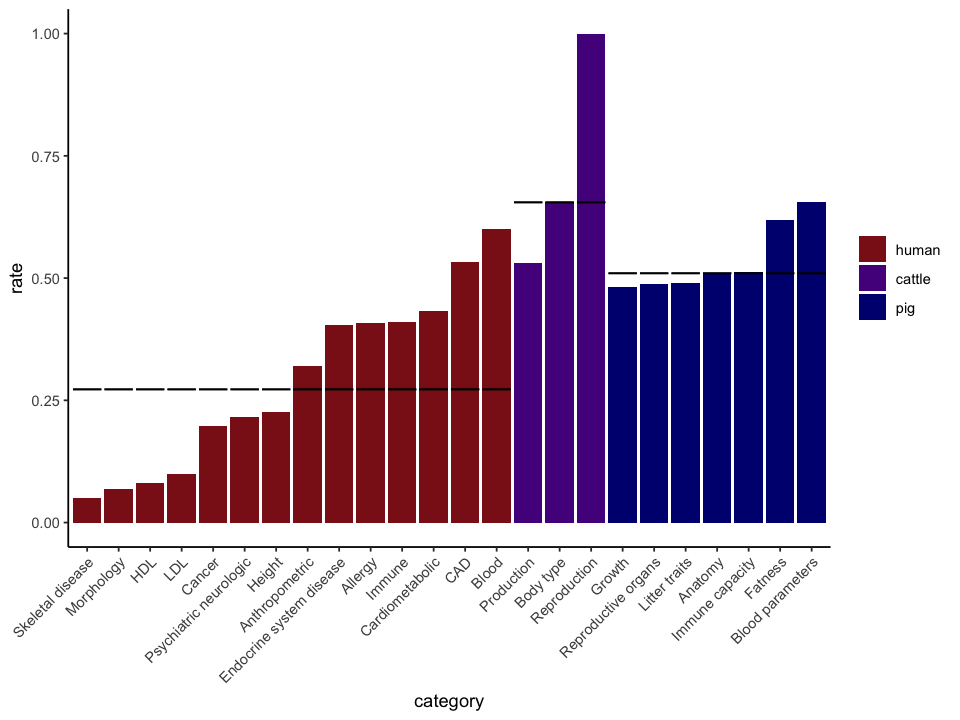

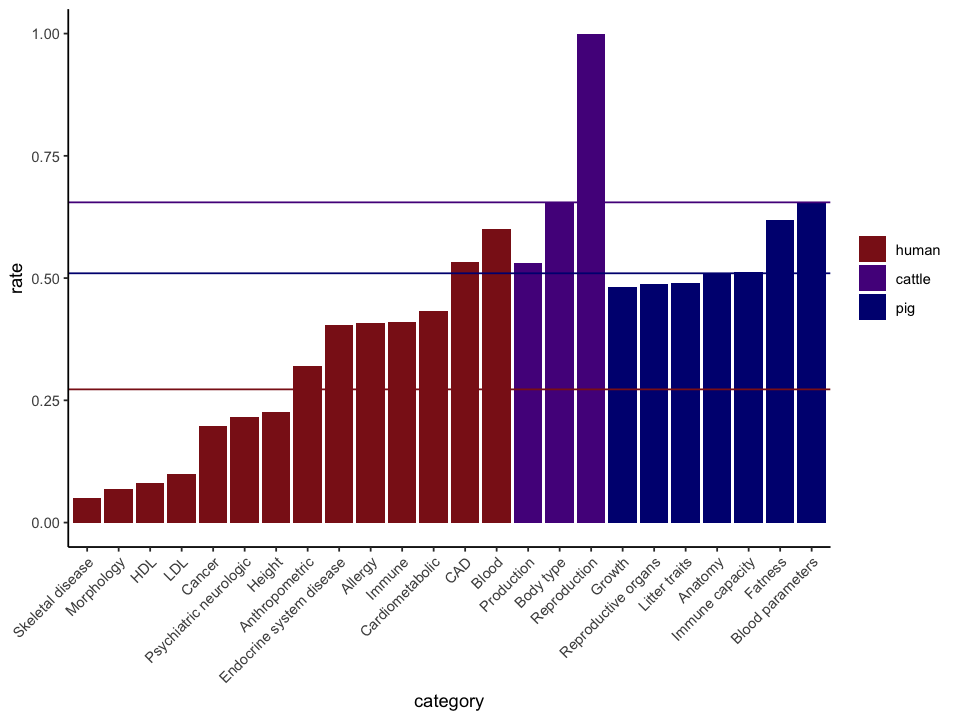

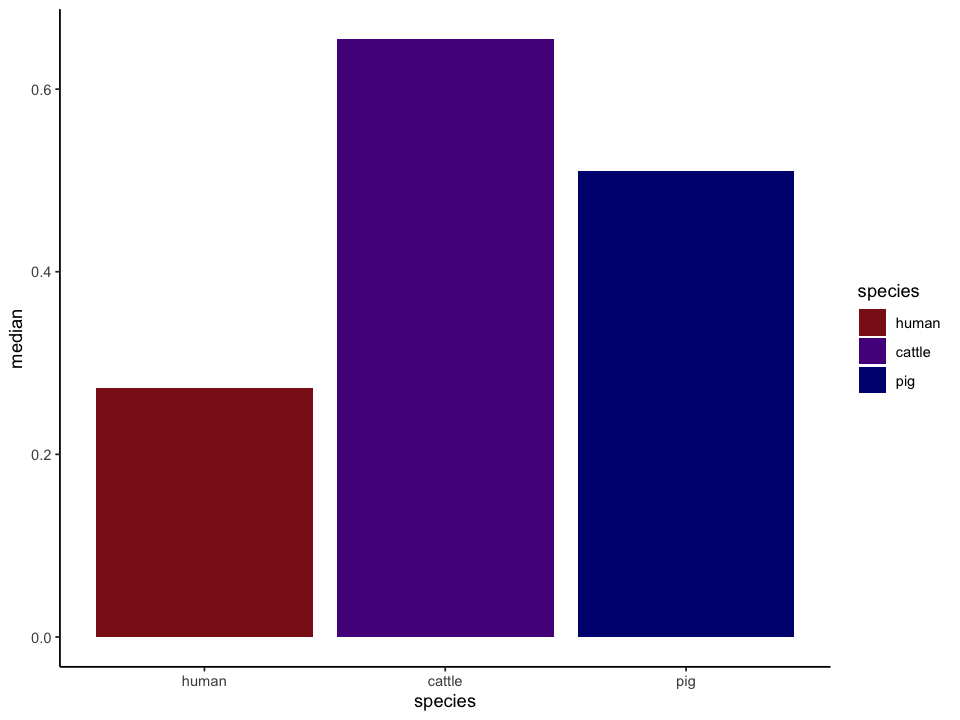

In [77]:
sp_enloc50_med = enloc50 %>% group_by(species) %>% mutate(median = median(rate)) %>% ungroup()
enloc50 %>%
    mutate(species = factor(species, levels=c('human', 'cattle', 'pig'))) %>%
    arrange(species, rate) %>%
    mutate(category = forcats::fct_inorder(category)) %>%
ggplot(aes(x=category, y=rate, fill=species, group_by=species)) + geom_col() +
    geom_errorbar(data=sp_enloc50_med, aes(x=category, y=median, ymin=median, ymax=median), guide='none') + 
    theme_classic() + 
    theme(axis.text.x=element_text(angle=45, hjust=1), legend.title=element_blank()) +
    # geom_hline(data=sp_enloc50_med, aes(yintercept=median, color=species), guide='none') +
    scale_fill_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']])) +
    scale_color_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']]))

sp_enloc50_med = enloc50 %>% group_by(species) %>% mutate(median = median(rate)) %>% ungroup()
enloc50 %>%
    mutate(species = factor(species, levels=c('human', 'cattle', 'pig'))) %>%
    arrange(species, rate) %>%
    mutate(category = forcats::fct_inorder(category)) %>%
ggplot(aes(x=category, y=rate, fill=species, group_by=species)) + geom_col() +
    # geom_errorbar(data=enloc50_med, aes(x=category, y=median, ymin=median, ymax=median), guide='none') + 
    theme_classic() + 
    theme(axis.text.x=element_text(angle=45, hjust=1), legend.title=element_blank()) +
    geom_hline(data=sp_enloc50_med, aes(yintercept=median, color=species), guide='none') +
    scale_fill_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']])) +
    scale_color_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']]), guide='none')

enloc50_med = enloc50 %>% group_by(species) %>% mutate(median = median(rate)) %>% ungroup()
enloc50_med %>% select(species, median) %>% distinct() %>%
    mutate(species = factor(species, levels=c('human', 'cattle', 'pig'))) %>%
ggplot(aes(x=species, fill=species, y=median)) + geom_col() + theme_classic() +
    scale_fill_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']]))


In [91]:
# teng_categories = data.frame(
#     category = c(' Health', ' Meat_and_Carcass', ' Production', ' Reproduction'),
#     rate = c(0.662, 0.599, 0.519, 0.507, 0.185, 0.212, 0.148, 0.209),
#     cutoff = c(0.5, 0.5, 0.5, 0.5, 0.9, 0.9, 0.9, 0.9),
#     gwas_loci = c(71, 563, 235, 655, 81, 576, 203, 647)
# )

# teng_categories$species = 'pig'
# teng_categories$study = 'Teng'

# enloc_by_category = rbind(
#     human_barbeira_categories,
#     human_hukku_categories,
#     liu_categories %>% rename(category=Categories, cutoff=rcp) %>% mutate(species='cattle', study='Liu') %>% select(-enloc_hits),
#     teng_categories
# ) %>%
# rowwise() %>%
# mutate(category = gsub('_', ' ', category))

enloc_by_category = rbind(
    human_barbeira_categories,
    human_hukku_categories,
    cattle_categories,
    pig_categories
) %>%
rowwise() %>%
mutate(category = gsub('_', ' ', category))

enloc50 = enloc_by_category[enloc_by_category$cutoff == 0.5, ] %>% # mutate(category = ifelse(category=='Skeletal system disease', 'Skeletal disease', category)) %>%
    filter(gwas_loci >= 20)
enloc50_med = enloc50 %>% group_by(study) %>% mutate(median = median(rate)) %>% ungroup()
enloc50_mean = enloc50 %>% group_by(study) %>% mutate(mean = sum(rate*gwas_loci)/sum(gwas_loci)) %>% ungroup()

### Plot

Warning message in geom_hline(data = sp_enloc50_med, aes(yintercept = median, color = species), :
“Ignoring unknown parameters: `guide`”


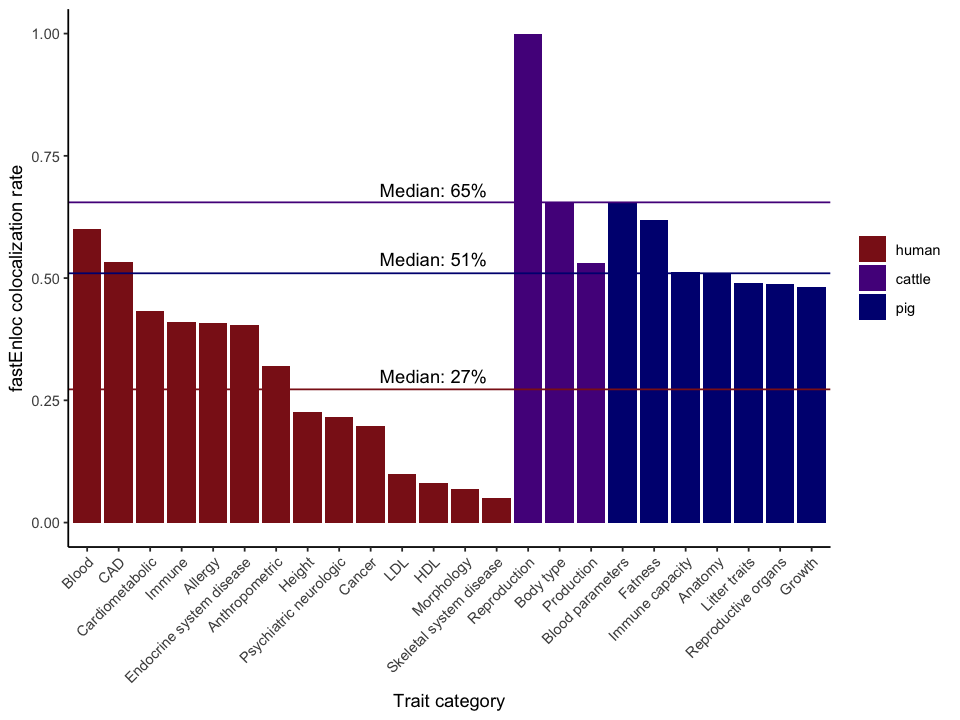

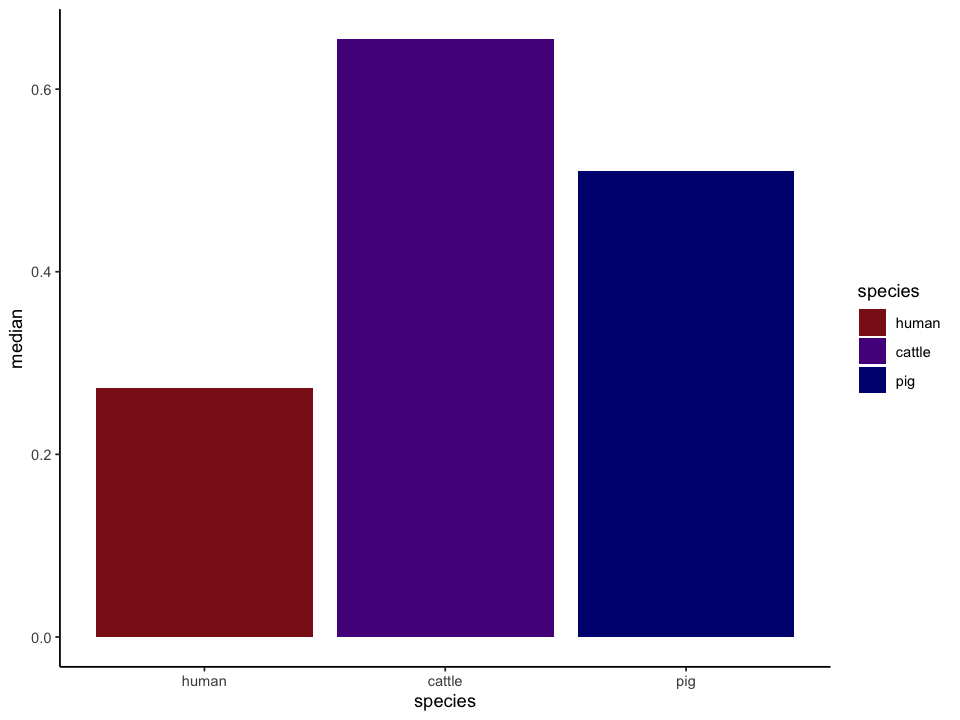

In [ ]:
fig_size(8,6)

sp_enloc50_med = enloc50 %>% group_by(species) %>% mutate(median = median(rate)) %>% ungroup()
# enloc50 %>%
#     mutate(species = factor(species, levels=c('human', 'cattle', 'pig'))) %>%
#     arrange(species, desc(rate)) %>%
#     mutate(category = forcats::fct_inorder(category)) %>%
# ggplot(aes(x=category, y=rate, fill=species, group_by=species)) + geom_col() +
#     geom_errorbar(data=sp_enloc50_med, aes(x=category, y=median, ymin=median, ymax=median), guide='none') + 
#     theme_classic() + 
#     theme(axis.text.x=element_text(angle=45, hjust=1), legend.title=element_blank()) +
#     # geom_hline(data=sp_enloc50_med, aes(yintercept=median, color=species), guide='none') +
#     scale_fill_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']])) +
#     scale_color_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']]))

sp_enloc50_med = enloc50 %>% group_by(species) %>% mutate(median = median(rate)) %>% ungroup()
enloc50 %>%
    mutate(species = factor(species, levels=c('human', 'cattle', 'pig'))) %>%
    arrange(species, desc(rate)) %>%
    mutate(category = forcats::fct_inorder(category)) %>%
ggplot(aes(x=category, y=rate, fill=species, group_by=species)) + geom_col() +
    # geom_errorbar(data=enloc50_med, aes(x=category, y=median, ymin=median, ymax=median), guide='none') + 
    theme_classic() + 
    theme(axis.text.x=element_text(angle=45, hjust=1), legend.title=element_blank()) +
    geom_hline(data=sp_enloc50_med, aes(yintercept=median, color=species), guide='none') +
    scale_fill_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']])) +
    scale_color_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']]), guide='none') +
    ylab('fastEnloc colocalization rate') + xlab('Trait category') + 
    ggplot2::annotate('text', x=12, y=0.30, label='Median: 27%') +
    ggplot2::annotate('text', x=12, y=0.54, label='Median: 51%') +
    ggplot2::annotate('text', x=12, y=0.68, label='Median: 65%')

# enloc50_med = enloc50 %>% group_by(species) %>% mutate(median = median(rate)) %>% ungroup()
# enloc50_med %>% select(species, median) %>% distinct() %>%
#     mutate(species = factor(species, levels=c('human', 'cattle', 'pig'))) %>%
# ggplot(aes(x=species, fill=species, y=median)) + geom_col() + theme_classic() +
#     scale_fill_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']]))


## Version used in presentations

Warning message in geom_hline(data = sp_enloc50_med, aes(yintercept = median, color = species), :
“Ignoring unknown parameters: `guide`”


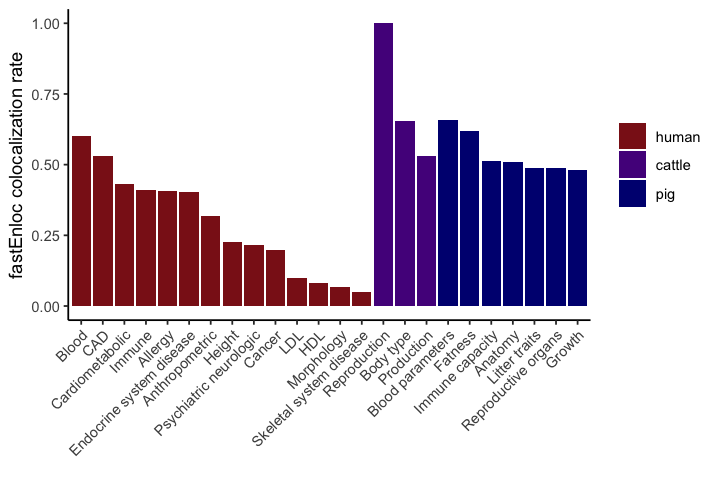

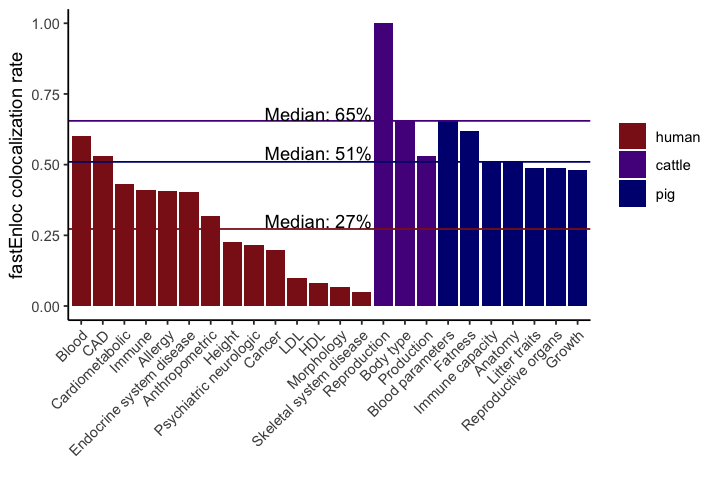

In [114]:
fig_size(6, 4)
sp_enloc50_med = enloc50 %>% group_by(species) %>% mutate(median = median(rate)) %>% ungroup()
enloc50 %>%
    mutate(species = factor(species, levels=c('human', 'cattle', 'pig'))) %>%
    arrange(species, desc(rate)) %>%
    mutate(category = forcats::fct_inorder(category)) %>%
ggplot(aes(x=category, y=rate, fill=species, group_by=species)) + geom_col() +
    # geom_errorbar(data=enloc50_med, aes(x=category, y=median, ymin=median, ymax=median), guide='none') + 
    theme_classic() + 
    theme(axis.text.x=element_text(angle=45, hjust=1), legend.title=element_blank()) +
    scale_fill_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']])) +
    scale_color_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']]), guide='none') +
    ylab('fastEnloc colocalization rate') + xlab(element_blank())

sp_enloc50_med = enloc50 %>% group_by(species) %>% mutate(median = median(rate)) %>% ungroup()
enloc50 %>%
    mutate(species = factor(species, levels=c('human', 'cattle', 'pig'))) %>%
    arrange(species, desc(rate)) %>%
    mutate(category = forcats::fct_inorder(category)) %>%
ggplot(aes(x=category, y=rate, fill=species, group_by=species)) + geom_col() +
    # geom_errorbar(data=enloc50_med, aes(x=category, y=median, ymin=median, ymax=median), guide='none') + 
    theme_classic() + 
    theme(axis.text.x=element_text(angle=45, hjust=1), legend.title=element_blank()) +
    geom_hline(data=sp_enloc50_med, aes(yintercept=median, color=species), guide='none') +
    scale_fill_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']])) +
    scale_color_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']]), guide='none') +
    ylab('fastEnloc colocalization rate') + xlab(element_blank()) + 
    ggplot2::annotate('text', x=12, y=0.30, label='Median: 27%') +
    ggplot2::annotate('text', x=12, y=0.54, label='Median: 51%') +
    ggplot2::annotate('text', x=12, y=0.68, label='Median: 65%')

## Non-categorical version--not used in paper

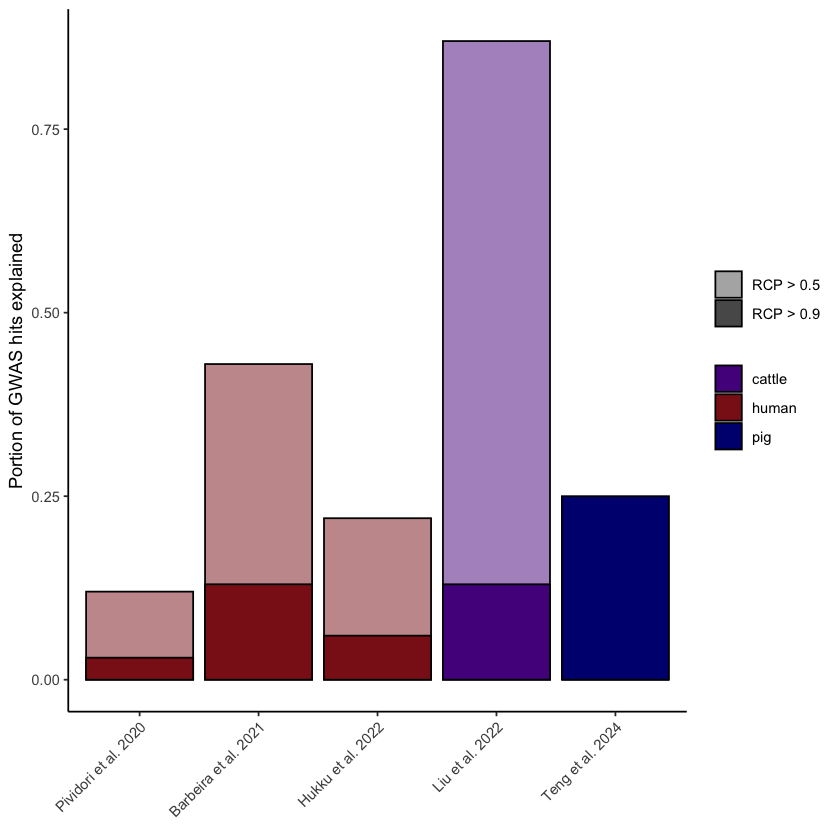

In [3]:
enloc %>% filter(study != 'Hukku et al. 2022 (simulated)', study != 'Barbeira et al. 2021 (no blood)') %>%
ggplot(aes(x=study, y=hits, fill=species, alpha=rcp)) + geom_bar(stat='identity', position='identity', color='black') + theme_classic() +
    scale_alpha_manual(values=c('0.5' = 0.5, '0.9' = 1), labels=c('RCP > 0.5', 'RCP > 0.9')) + 
    theme(axis.text.x=element_text(angle=45, hjust=1), legend.title=element_blank()) + xlab(element_blank()) + ylab('Portion of GWAS hits explained') +
    scale_fill_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']]))

## Figure 1B

[1] 235

[1] 136.5

[1] 86

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


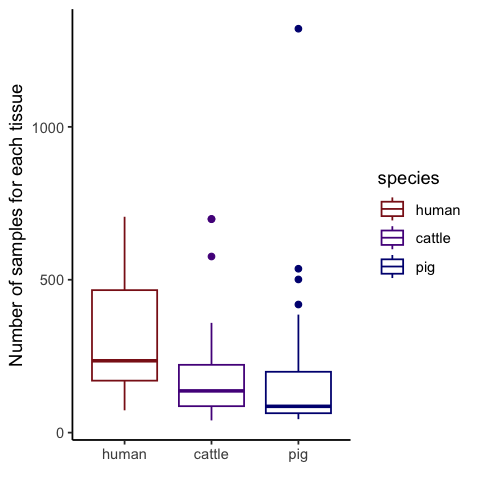

In [117]:
median(human_tissue_n)
median(cattle_tissue_n)
median(pig_tissue_n)

fig_size(4,4)

rbind(
    data.frame(species = 'human', n = human_tissue_n),
    data.frame(species = 'cattle', n = cattle_tissue_n),
    data.frame(species = 'pig', n = pig_tissue_n)
) %>% 
mutate(species = factor(species, levels=c('human', 'cattle', 'pig'))) %>%
ggplot(aes(x = species, y = n, color=species)) + geom_boxplot() + theme_classic() + xlab(element_blank()) + ylab('Number of samples for each tissue') +
    scale_color_manual(values=c('human'='firebrick1', 'cattle'='purple', 'pig'='royalblue1')) + 
    scale_color_manual(values=c('human'=color_key[['human']], 'pig'=color_key[['pig']], 'cattle'=color_key[['cattle']]))

# Determining rates

## Prelim

## Pividori *et al.* 2020; PhenomeXcan: Mapping the genome to the phenome through the transcriptome

Both supplementary tables can be downloaded from [the paper](https://www.science.org/doi/10.1126/sciadv.aba2083#core-R26-1).

[S1](https://www.science.org/action/downloadSupplement?doi=10.1126%2Fsciadv.aba2083&file=aba2083_table_s1.xlsx)

[S2](https://www.science.org/action/downloadSupplement?doi=10.1126%2Fsciadv.aba2083&file=aba2083_table_s2.xlsx)

In [23]:
# Change to match your data directory
ddir = '~/Downloads/'

s1 = read_excel(paste0(ddir, 'aba2083_table_s1.xlsx'))
s2 = read_excel(paste0(ddir, 'aba2083_table_s2.xlsx'))

The paper reports: “We found 72,994 significant associations (Bonferroni-corrected P value of <5.49 × 10−10) across the entire genome/phenome space, where 22,219 (30.5%) had locus RCP >0.1 (table S1). We constructed a quantile-quantile plot of all associations, which did not show evidence of systematic inflation (fig. S1). These associations represent numerous potential targets for translational studies with biological support.”

In [24]:
cat(paste('Confirm the total number of hits at RCP > 0.1:\t', sum(s1$fastenloc_rcp > 0.1), '\n'))
cat(paste('Check the number of hits at RCP > 0.5:\t', sum(s1$fastenloc_rcp > 0.5), '\n'))
cat(paste('Check the number of hits at RCP > 0.9:\t', sum(s1$fastenloc_rcp > 0.9)))

Confirm the total number of hits at RCP > 0.1:	 22219 
Check the number of hits at RCP > 0.5:	 8930 
Check the number of hits at RCP > 0.9:	 2180

**Our uniform threshold for comparing studies is RCP > 0.5, so the adjusted success rate is 12.6%**

(0.305 x 8,930/22,219 = 0.126)

Pividori et al. also looked at a set of 7,809 "high-confidence gene-trait associations from OMIM."

We can read those in from s2, and see how many of them are identified by fastEnloc.

In [25]:
cat('Confirm the number of high-confidence gene-trait associations:', nrow(s2))

Confirm the number of high-confidence gene-trait associations: 7809

How many of these are identified with fastEnloc at different thresholds?

In [26]:
rcp1 = sum(s2$ensembl_gene_id %in% s1$gene_id[s1$fastenloc_rcp > 0.1])
cat('Number of high-confidence gene-trait associations with fastEnloc RCP > 0.1:', rcp1, '\n')
rcp5 = sum(s2$ensembl_gene_id %in% s1$gene_id[s1$fastenloc_rcp > 0.5])
cat('Number of high-confidence gene-trait associations with fastEnloc RCP > 0.5:', rcp5, '\n')
rcp9 = sum(s2$ensembl_gene_id %in% s1$gene_id[s1$fastenloc_rcp > 0.9])
cat('Number of high-confidence gene-trait associations with fastEnloc RCP > 0.9:', rcp9, '\n')


Number of high-confidence gene-trait associations with fastEnloc RCP > 0.1: 2364 
Number of high-confidence gene-trait associations with fastEnloc RCP > 0.5: 1441 
Number of high-confidence gene-trait associations with fastEnloc RCP > 0.9: 465 


So using the same standard of RCP > 0.5, we identify 18.4% of the high-confidence gene-trait associations with fastEnloc.

(1,441 / 7,809)

Using the cutoff of RCP > 0.5, we identify 6% of the high-confidence gene-trait associations with fastEnloc.

(465 / 7,809)

## Barbeira *et al.* 2021 (data correspond to GTEx Consortium et al. 2020)

The enloc data for this study can be downloaded from [Zenodo](https://zenodo.org/records/3518299#.XbMgFNF7m90).

However, it is simplier to use the processed [counts per-region](https://raw.githubusercontent.com/hakyimlab/gtex-gwas-analysis/master/data/summaries/mashr_regions.txt), along with the [trait categories](blob:https://github.com/e9ec88d8-d88e-4972-9802-3e02fb2e3742).

In [20]:
# Change to match your data directory
ddir = '~/eqtl_selection/data/enloc/henloc/barbeira_2021/'

In [21]:
gwas_regions = read.table(paste0(ddir, 'mashr_regions.txt'), header=T, as.is=T, sep='\t')

counts = read.table(paste0(ddir, 'count.txt'), header=T, as.is=T, sep='\t', comment.char='') %>%
    select(trait, category) %>%
    rename(phenotype=trait) %>%
    distinct()

gwas_regions = gwas_regions %>% 
    left_join(counts, by='phenotype')

numer = gwas_regions %>% filter(method == 'enloc_eqtl') %>% group_by(phenotype) %>% summarize(n=n()) %>% pull(n) %>% sum()
denom = gwas_regions %>% filter(method == 'gwas') %>% group_by(phenotype) %>% summarize(n=n()) %>% pull(n) %>% sum()
cat('The portion of all loci explained is:', round(numer / denom, 2), '(', numer, '/', denom, ')')

The portion of all loci explained is: 0.43 ( 2303 / 5385 )

In [30]:
# Import the regions and keep only those that are also gwas hits
pheno_reg = paste(gwas_regions$region[gwas_regions$method=='gwas'], gwas_regions$phenotype[gwas_regions$method=='gwas'])
reg_rcp = read.table('~/eqtl_selection/data/enloc/henloc/barbeira_2021/mashr_regions_enloc_eqtl.txt', header=T, as.is=T) %>% 
    filter(paste(region, phenotype) %in% pheno_reg) %>% 
    left_join(counts, by='phenotype')

gwas_regions = gwas_regions %>% left_join(reg_rcp %>% mutate(method='enloc_eqtl'))

portion_of_loci_categorical = function(categ, rcp=0.5) {
    numer = gwas_regions %>% filter(category == categ, method == 'enloc_eqtl', best_rcp >=rcp) %>% nrow()
    denom = gwas_regions %>% filter(category == categ, method == 'gwas') %>% nrow()
    cat('The portion of loci explained in category', tolower(categ), 'is:\t', round(numer/denom, 2), ' ( ', numer, ' / ', denom, ' ) ', '\n')
    return(numer/denom)
}

categories = unique(gwas_regions$category)
tmp = sapply(categories, portion_of_loci_categorical)

# human_berbeira_categories = data.frame(
#     category = c(unique(gwas_regions$category), unique(gwas_regions$category)),
#     cutoff = c(rep(0.5, length(unique(gwas_regions$category))), rep(0.9, length(unique(gwas_regions$category))))
# ) %>% mutate(
#     species = 'human',
#     study = 'Hukku'
# )

human_barbeira_categories = data.frame(
    category = c(unique(gwas_regions$category)),
    cutoff = c(rep(0.5, length(unique(gwas_regions$category))), rep(0.9, length(unique(gwas_regions$category))))
) %>% rowwise() %>%
mutate(
    rate = portion_of_loci_categorical(category, rcp=cutoff),
    species = 'human',
    study = 'Barbeira',
    gwas_loci = sum(gwas_regions$category == category)
)

Joining with `by = join_by(region, phenotype, count, method, category)`


The portion of loci explained in category blood is:	 0.6  (  1269  /  2115  )  
The portion of loci explained in category anthropometric is:	 0.32  (  552  /  1728  )  
The portion of loci explained in category immune is:	 0.41  (  178  /  435  )  
The portion of loci explained in category psychiatric_neurologic is:	 0.22  (  72  /  334  )  
The portion of loci explained in category allergy is:	 0.41  (  33  /  81  )  
The portion of loci explained in category cancer is:	 0.2  (  16  /  81  )  
The portion of loci explained in category morphology is:	 0.07  (  13  /  192  )  
The portion of loci explained in category cardiometabolic is:	 0.43  (  132  /  305  )  
The portion of loci explained in category endocrine system disease is:	 0.4  (  36  /  89  )  
The portion of loci explained in category skeletal system disease is:	 0.05  (  1  /  20  )  
The portion of loci explained in category aging is:	 0.2  (  1  /  5  )  
The portion of loci explained in category blood is:	 0.6  (  1269

We also filter out the category with too few GWAS loci (aging).

In [33]:
human_barbeira_categories = human_barbeira_categories %>% filter(gwas_loci > 20)

In [23]:
portion_of_loci = function(name) {
    reg = paste0('^', name)
    numer = gwas_regions %>% filter(grepl(reg, phenotype, ignore.case=T), method == 'enloc_eqtl') %>% group_by(phenotype) %>% nrow()
    denom = gwas_regions %>% filter(grepl(reg, phenotype, ignore.case=T), method == 'gwas') %>% group_by(phenotype) %>% nrow()
    cat('The portion of', name, 'loci explained is:', str_pad(signif(numer/denom, 2), 15-nchar(name), side='left'), '(', numer, '/', denom, ')\n')
}

gwas_categories = gwas_regions %>% mutate(phenotype = gsub('[._].*', '', phenotype)) %>% pull(phenotype) %>% toupper() %>% unique()

tmp = sapply(gwas_categories, portion_of_loci)

The portion of ASTLE loci explained is:        0.6 ( 1269 / 2115 )
The portion of UKB loci explained is:          0.3 ( 684 / 2292 )
The portion of GIANT loci explained is:       0.34 ( 137 / 402 )
The portion of BCAC loci explained is:         0.2 ( 16 / 81 )
The portion of RA loci explained is:          0.58 ( 31 / 53 )
The portion of PGC loci explained is:         0.36 ( 26 / 73 )
The portion of IBD loci explained is:         0.51 ( 69 / 134 )
The portion of MAGIC loci explained is:          0 ( 0 / 11 )
The portion of CARDIOGRAM loci explained is:  0.79 ( 27 / 34 )
The portion of MAGNETIC loci explained is:    0.19 ( 8 / 42 )
The portion of EGG loci explained is:         0.53 ( 18 / 34 )
The portion of IMMUNOBASE loci explained is:  0.12 ( 5 / 40 )
The portion of SSGAC loci explained is:       0.19 ( 9 / 47 )
The portion of IGAP loci explained is:       0.091 ( 1 / 11 )
The portion of GEFOS loci explained is:          0 ( 0 / 1 )
The portion of EAGLE loci explained is:       0.43 (

Note that ASTLE loci are blood traits, which overall tend to colocalize at high rates

In [24]:
portion_of_loci = function(name) {
    reg = paste0('^', name)
    numer = gwas_regions %>% filter(grepl(reg, phenotype, ignore.case=T), method == 'enloc_eqtl') %>% group_by(phenotype) %>% nrow()
    denom = gwas_regions %>% filter(grepl(reg, phenotype, ignore.case=T), method == 'gwas') %>% group_by(phenotype) %>% nrow()
    cat('The portion of', name, 'loci explained is:', str_pad(signif(numer/denom, 2), 60-nchar(name), side='left'), '(', numer, '/', denom, ')\n')
}

astle_names = gwas_regions %>% filter(grepl('Astle', phenotype)) %>% pull(phenotype) %>% unique()

tmp = sapply(astle_names, portion_of_loci)

The portion of Astle_et_al_2016_Reticulocyte_count loci explained is:                      0.63 ( 90 / 142 )
The portion of Astle_et_al_2016_Lymphocyte_counts loci explained is:                       0.61 ( 89 / 147 )
The portion of Astle_et_al_2016_Monocyte_count loci explained is:                           0.6 ( 105 / 175 )
The portion of Astle_et_al_2016_Sum_eosinophil_basophil_counts loci explained is:          0.47 ( 73 / 154 )
The portion of Astle_et_al_2016_Platelet_count loci explained is:                          0.58 ( 122 / 209 )
The portion of Astle_et_al_2016_Neutrophil_count loci explained is:                        0.65 ( 85 / 130 )
The portion of Astle_et_al_2016_Red_blood_cell_count loci explained is:                    0.54 ( 92 / 169 )
The portion of Astle_et_al_2016_Myeloid_white_cell_count loci explained is:                0.67 ( 90 / 134 )
The portion of Astle_et_al_2016_Granulocyte_count loci explained is:                       0.66 ( 87 / 132 )
The portion of As

Blood traits have a large effect on the rate of colocalization. Remember, the overall rate is 42%.

In [53]:
cat('Portion of loci explained excluding Astle et al. 2016 (i.e., non-blood traits):\t')
cat(round(gwas_regions %>% filter(method == 'enloc_eqtl' & !grepl('astle', phenotype, ignore.case=T)) %>% nrow() / gwas_regions %>% filter(method == 'gwas' & !grepl('astle', phenotype, ignore.case=T)) %>% nrow(), 2), '\n')

cat('Portion of loci explained from Astle et al. 2016 (i.e., blood traits):\t\t')
cat(round(gwas_regions %>% filter(method == 'enloc_eqtl' & grepl('astle', phenotype, ignore.case=T)) %>% nrow() / gwas_regions %>% filter(method == 'gwas' & grepl('astle', phenotype, ignore.case=T)) %>% nrow(), 2))

Portion of loci explained excluding Astle et al. 2016 (i.e., non-blood traits):	0.32 
Portion of loci explained from Astle et al. 2016 (i.e., blood traits):		0.6

What portion of fastEnloc hits remain when we change the RCP cutoff to 0.9?

In [58]:
# Import the regions and keep only those that are also gwas hits
pheno_reg = paste(gwas_regions$region[gwas_regions$method=='gwas'], gwas_regions$phenotype[gwas_regions$method=='gwas'])
reg_rcp = read.table('~/eqtl_selection/data/enloc/henloc/barbeira_2021/mashr_regions_enloc_eqtl.txt', header=T, as.is=T) %>% 
    filter(paste(region, phenotype) %in% pheno_reg) %>% 
    left_join(counts, by='phenotype')

cat('All traits\n')
cat('  ', round(sum(reg_rcp$best_rcp > 0.9)/nrow(reg_rcp), 2))
cat('\n')
cat('Blood traits\n')
cat('  ', round(sum(reg_rcp$best_rcp > 0.9 & reg_rcp$category == 'Blood')/sum(reg_rcp$category == 'Blood'), 2))
cat('\n')
cat('Non-blood traits\n')
cat('  ', round(sum(reg_rcp$best_rcp > 0.9 & reg_rcp$category != 'Blood')/sum(reg_rcp$category != 'Blood'), 2))

All traits
   0.31
Blood traits
   0.36
Non-blood traits
   0.24

Accounting for the initial success:

All traits: 0.31 x 0.43 = 0.13

Blood: 0.60 x 0.36 = 0.22

Non-blood: 0.32 x 0.24 = 0.08

## Hukku *et al.* 2022; Analyzing and reconciling colocalization and transcriptome-wide association studies from the perspective of inferential reproducibility

Hukku et al. uses two definitions of "locus":
1. Loci for the eQTL traits are based on signal clusters (see section "Specification of candidate colocalization loci")
2. Loci for the GWAS are based on the same LD-independent regions from Berissa and Pickrell 2015.

Downloaded the data from [github](https://github.com/xqwen/TWAS_vs_coloc/tree/main/gtex_gwas_analysis/fastENLOC_output) and from [google drive](https://drive.usercontent.google.com/download?id=1X8utOqslKD-upD45C2HNYB7267fXSPhW&export=download&authuser=0)

First we check how many of the LD-independent loci have genome-wide significant association.

In [50]:
ddir = '~/eqtl_selection/data/enloc/henloc/other_hukku_data/torus/'

zcut = abs(qnorm(5e-8))
ldl_loc = read.table(paste0(ddir, 'LDL.torus.zval.gz'), header=F, as.is=T) %>% 
    filter(abs(V3) >= zcut) %>% 
    pull(V2) %>%
    unique()

hdl_loc = read.table(paste0(ddir, 'HDL.torus.zval.gz'), header=F, as.is=T) %>% 
    filter(abs(V3) >= zcut) %>% 
    pull(V2) %>%
    unique()

cad_loc = read.table(paste0(ddir, 'CAD.torus.zval.gz'), header=F, as.is=T) %>% 
    filter(abs(V3) >= zcut) %>% 
    pull(V2) %>%
    unique()

heights_loc = read.table(paste0(ddir, 'Heights.torus.zval.gz'), header=F, as.is=T) %>% 
    filter(abs(V3) >= zcut) %>% 
    pull(V2) %>%
    unique()

cat('Number of LDL loci with genome-wide significant association:', length(ldl_loc), '\n')
cat('Number of HDL loci with genome-wide significant association:', length(hdl_loc), '\n')
cat('Number of CAD loci with genome-wide significant association:', length(cad_loc), '\n')
cat('Number of height loci with genome-wide significant association:', length(heights_loc))

Number of LDL loci with genome-wide significant association: 80 
Number of HDL loci with genome-wide significant association: 98 
Number of CAD loci with genome-wide significant association: 47 
Number of height loci with genome-wide significant association: 772

First we collapse all tissue results (we're not worried about distinctions between tissues), then read them in with a baseline cutoff of RCP > 0.1.

This is a later version of fastEnloc, so LCP is available (and preferred). But we're ultimately going to use RCP for the sake of comparison.

In [51]:
# We combine fastEnloc outputs for convenience
# This directory is from downloading the github above
ddir = '~/tmp/TWAS_vs_coloc/gtex_gwas_analysis/fastENLOC_output/'

system(paste0("awk 'NR == 1 || FNR > 1' ", ddir, "LDL*sig.out > ", ddir, "all_ldl_sig.out"))
system(paste0("awk 'NR == 1 || FNR > 1' ", ddir, "HDL*sig.out > ", ddir, "all_hdl_sig.out"))
system(paste0("awk 'NR == 1 || FNR > 1' ", ddir, "CAD*sig.out > ", ddir, "all_cad_sig.out"))
system(paste0("awk 'NR == 1 || FNR > 1' ", ddir, "Heights*sig.out > ", ddir, "all_heights_sig.out"))

In [52]:
# This directory is from downloading the github above
ddir = '~/tmp/TWAS_vs_coloc/gtex_gwas_analysis/fastENLOC_output/'

ldl_enloc = read.table(paste0(ddir, 'all_ldl_sig.out'), header=T, as.is=T) %>%
    filter(LCP >= 0.1) %>%
    tidyr::separate_wider_delim(Signal, delim='(@)', names=c('gene', 'locus'))

hdl_enloc = read.table(paste0(ddir, 'all_hdl_sig.out'), header=T, as.is=T) %>%
    filter(LCP >= 0.1) %>%
    tidyr::separate_wider_delim(Signal, delim='(@)', names=c('gene', 'locus'))

cad_enloc = read.table(paste0(ddir, 'all_cad_sig.out'), header=T, as.is=T) %>%
    filter(LCP >= 0.1) %>%
    tidyr::separate_wider_delim(Signal, delim='(@)', names=c('gene', 'locus'))

heights_enloc = read.table(paste0(ddir, 'all_heights_sig.out'), header=T, as.is=T) %>%
    filter(LCP >= 0.1) %>%
    tidyr::separate_wider_delim(Signal, delim='(@)', names=c('gene', 'locus'))

Now we look at enloc hits using RCP (regional colocalization probability). We use RCP for consistency across comparisons. However, this version of fastEnloc also produces LCP (locus colocalization probability), which has substantially higher power. The LCP results are also included below for completeness.

In [65]:
count_loci = function(df, cutoff) {
    loci = df %>% filter(RCP > cutoff) %>% pull(locus)
    return(length(unique(loci)))
}

cat('Number of loci colocalized using fastEnloc\n(This includes loci that do not reach genome-wide significance in the GWAS)\n')
cat('RCP > 0.1\n')
cat('\tLDL:\t', count_loci(ldl_enloc, 0.1), '\n')
cat('\tHDL:\t', count_loci(hdl_enloc, 0.1), '\n')
cat('\tCAD:\t', count_loci(cad_enloc, 0.1), '\n')
cat('\tHeight:\t', count_loci(heights_enloc, 0.1), '\n')
cat('----------------------------------------------\n')
cat('RCP > 0.5\n')
cat('\tLDL:\t', count_loci(ldl_enloc, 0.5), '\n')
cat('\tHDL:\t', count_loci(hdl_enloc, 0.5), '\n')
cat('\tCAD:\t', count_loci(cad_enloc, 0.5), '\n')
cat('\tHeight:\t', count_loci(heights_enloc, 0.5), '\n')
cat('----------------------------------------------\n')
cat('RCP > 0.9\n')
cat('\tLDL:\t', count_loci(ldl_enloc, 0.9), '\n')
cat('\tHDL:\t', count_loci(hdl_enloc, 0.9), '\n')
cat('\tCAD:\t', count_loci(cad_enloc, 0.9), '\n')
cat('\tHeight:\t', count_loci(heights_enloc, 0.9), '\n')

cat('----------------------------------------------\n')

count_loci_intersect = function(df, cutoff, loc_list) {
    loci = df %>% filter(RCP > cutoff, locus %in% loc_list) %>% pull(locus)
    return(length(unique(loci)))
}

cat('Number of GWAS loci colocalized using fastEnloc\n')
cat('RCP > 0.1\n')
cat('\tLDL:\t', count_loci_intersect(ldl_enloc, 0.1, ldl_loc), '\n')
cat('\tHDL:\t', count_loci_intersect(hdl_enloc, 0.1, hdl_loc), '\n')
cat('\tCAD:\t', count_loci_intersect(cad_enloc, 0.1, cad_loc), '\n')
cat('\tHeight:\t', count_loci_intersect(heights_enloc, 0.1, heights_loc), '\n')
cat('RCP > 0.5\n')
cat('\tLDL:\t', count_loci_intersect(ldl_enloc, 0.5, ldl_loc), '\n')
cat('\tHDL:\t', count_loci_intersect(hdl_enloc, 0.5, hdl_loc), '\n')
cat('\tCAD:\t', count_loci_intersect(cad_enloc, 0.5, cad_loc), '\n')
cat('\tHeight:\t', count_loci_intersect(heights_enloc, 0.5, heights_loc), '\n')

cat('RCP > 0.9\n')
cat('\tLDL:\t', count_loci_intersect(ldl_enloc, 0.9, ldl_loc), '\n')
cat('\tHDL:\t', count_loci_intersect(hdl_enloc, 0.9, hdl_loc), '\n')
cat('\tCAD:\t', count_loci_intersect(cad_enloc, 0.9, cad_loc), '\n')
cat('\tHeight:\t', count_loci_intersect(heights_enloc, 0.9, heights_loc), '\n')

cat('----------------------------------------------\n')

count_loci_portion = function(df, cutoff, loc_list) {
    loci = df %>% filter(RCP > cutoff, locus %in% loc_list) %>% pull(locus)
    return(length(unique(loci))/length(loc_list))
}

cat('Portion of GWAS loci colocalized using fastEnloc\n(RCP > 0.5)\n')
cat('\tLDL:\t', count_loci_portion(ldl_enloc, 0.5, ldl_loc), '\n')
cat('\tHDL:\t', count_loci_portion(hdl_enloc, 0.5, hdl_loc), '\n')
cat('\tCAD:\t', count_loci_portion(cad_enloc, 0.5, cad_loc), '\n')
cat('\tHeight:\t', count_loci_portion(heights_enloc, 0.5, heights_loc), '\n')
cat('\tTotal:\t', round(sum(count_loci_intersect(ldl_enloc, 0.5, ldl_loc), count_loci_intersect(hdl_enloc, 0.5, hdl_loc), count_loci_intersect(cad_enloc, 0.5, cad_loc), count_loci_intersect(heights_enloc, 0.5, heights_loc)) / sum(length(ldl_loc), length(hdl_loc), length(cad_loc), length(heights_loc)), 2))


cat('\nPortion of GWAS loci colocalized using fastEnloc\n(RCP > 0.9)\n')
cat('\tLDL:\t', count_loci_portion(ldl_enloc, 0.9, ldl_loc), '\n')
cat('\tHDL:\t', count_loci_portion(hdl_enloc, 0.9, hdl_loc), '\n')
cat('\tCAD:\t', count_loci_portion(cad_enloc, 0.9, cad_loc), '\n')
cat('\tHeight:\t', count_loci_portion(heights_enloc, 0.9, heights_loc), '\n')
cat('\tTotal:\t', round(sum(count_loci_intersect(ldl_enloc, 0.9, ldl_loc), count_loci_intersect(hdl_enloc, 0.9, hdl_loc), count_loci_intersect(cad_enloc, 0.9, cad_loc), count_loci_intersect(heights_enloc, 0.9, heights_loc)) / sum(length(ldl_loc), length(hdl_loc), length(cad_loc), length(heights_loc)), 2))

human_hukku_categories = data.frame(
    category = c('LDL', 'HDL', 'CAD', 'Height', 'LDL', 'HDL', 'CAD', 'Height'),
    cutoff = c(0.5, 0.5, 0.5, 0.5, 0.9, 0.9, 0.9, 0.9),
    rate = c(
        count_loci_portion(ldl_enloc, 0.5, ldl_loc),
        count_loci_portion(hdl_enloc, 0.5, hdl_loc),
        count_loci_portion(cad_enloc, 0.5, cad_loc),
        count_loci_portion(heights_enloc, 0.5, heights_loc),
        count_loci_portion(ldl_enloc, 0.9, ldl_loc),
        count_loci_portion(hdl_enloc, 0.9, hdl_loc),
        count_loci_portion(cad_enloc, 0.9, cad_loc),
        count_loci_portion(heights_enloc, 0.9, heights_loc)
    ),
    gwas_loci = c(
        length(ldl_loc),
        length(hdl_loc),
        length(cad_loc),
        length(heights_loc),
        length(ldl_loc),
        length(hdl_loc),
        length(cad_loc),
        length(heights_loc)
    )
) %>% mutate(
    species = 'human',
    study = 'Hukku'
)


Number of loci colocalized using fastEnloc
(This includes loci that do not reach genome-wide significance in the GWAS)
RCP > 0.1
	LDL:	 66 
	HDL:	 69 
	CAD:	 292 
	Height:	 741 
----------------------------------------------
RCP > 0.5
	LDL:	 10 
	HDL:	 13 
	CAD:	 83 
	Height:	 215 
----------------------------------------------
RCP > 0.9
	LDL:	 2 
	HDL:	 5 
	CAD:	 17 
	Height:	 39 
----------------------------------------------
Number of GWAS loci colocalized using fastEnloc
RCP > 0.1
	LDL:	 36 
	HDL:	 39 
	CAD:	 38 
	Height:	 452 
RCP > 0.5
	LDL:	 8 
	HDL:	 8 
	CAD:	 25 
	Height:	 174 
RCP > 0.9
	LDL:	 2 
	HDL:	 5 
	CAD:	 13 
	Height:	 35 
----------------------------------------------
Portion of GWAS loci colocalized using fastEnloc
(RCP > 0.5)
	LDL:	 0.1 
	HDL:	 0.08163265 
	CAD:	 0.5319149 
	Height:	 0.2253886 
	Total:	 0.22
Portion of GWAS loci colocalized using fastEnloc
(RCP > 0.9)
	LDL:	 0.025 
	HDL:	 0.05102041 
	CAD:	 0.2765957 
	Height:	 0.04533679 
	Total:	 0.06

In [64]:
count_loci = function(df, cutoff) {
    loci = df %>% filter(LCP > cutoff) %>% pull(locus)
    return(length(unique(loci)))
}

cat('Number of loci colocalized using fastEnloc\n')
cat('LCP > 0.1\n')
cat('\tLDL:\t', count_loci(ldl_enloc, 0.1), '\n')
cat('\tHDL:\t', count_loci(hdl_enloc, 0.1), '\n')
cat('\tCAD:\t', count_loci(cad_enloc, 0.1), '\n')
cat('\tHeight:\t', count_loci(heights_enloc, 0.1), '\n')

cat('LCP > 0.5\n')
cat('\tLDL:\t', count_loci(ldl_enloc, 0.5), '\n')
cat('\tHDL:\t', count_loci(hdl_enloc, 0.5), '\n')
cat('\tCAD:\t', count_loci(cad_enloc, 0.5), '\n')
cat('\tHeight:\t', count_loci(heights_enloc, 0.5), '\n')

cat('LCP > 0.9\n')
cat('\tLDL:\t', count_loci(ldl_enloc, 0.9), '\n')
cat('\tHDL:\t', count_loci(hdl_enloc, 0.9), '\n')
cat('\tCAD:\t', count_loci(cad_enloc, 0.9), '\n')
cat('\tHeight:\t', count_loci(heights_enloc, 0.9), '\n')

cat('----------------------------------------------\n')

count_loci_intersect = function(df, cutoff, loc_list) {
    loci = df %>% filter(LCP > cutoff, locus %in% loc_list) %>% pull(locus)
    return(length(unique(loci)))
}

cat('Number of GWAS loci colocalized using fastEnloc\n')
cat('LCP > 0.1\n')
cat('\tLDL:\t', count_loci_intersect(ldl_enloc, 0.1, ldl_loc), '\n')
cat('\tHDL:\t', count_loci_intersect(hdl_enloc, 0.1, hdl_loc), '\n')
cat('\tCAD:\t', count_loci_intersect(cad_enloc, 0.1, cad_loc), '\n')
cat('\tHeight:\t', count_loci_intersect(heights_enloc, 0.1, heights_loc), '\n')

cat('LCP > 0.5\n')
cat('\tLDL:\t', count_loci_intersect(ldl_enloc, 0.5, ldl_loc), '\n')
cat('\tHDL:\t', count_loci_intersect(hdl_enloc, 0.5, hdl_loc), '\n')
cat('\tCAD:\t', count_loci_intersect(cad_enloc, 0.5, cad_loc), '\n')
cat('\tHeight:\t', count_loci_intersect(heights_enloc, 0.5, heights_loc), '\n')

# cat('LCP > 0.9\n')
# cat('\tLDL:\t', count_loci_intersect(ldl_enloc, 0.9, ldl_loc), '\n')
# cat('\tHDL:\t', count_loci_intersect(hdl_enloc, 0.9, hdl_loc), '\n')
# cat('\tCAD:\t', count_loci_intersect(cad_enloc, 0.9, cad_loc), '\n')
# cat('\tHeight:\t', count_loci_intersect(heights_enloc, 0.9, heights_loc), '\n')

cat('----------------------------------------------\n')

count_loci_portion = function(df, cutoff, loc_list) {
    loci = df %>% filter(LCP > cutoff, locus %in% loc_list) %>% pull(locus)
    return(round(length(unique(loci))/length(loc_list), 2))
}

cat('Portion of GWAS loci colocalized using fastEnloc\n(LCP > 0.5)\n')
cat('\tLDL:\t', count_loci_portion(ldl_enloc, 0.5, ldl_loc), '\n')
cat('\tHDL:\t', count_loci_portion(hdl_enloc, 0.5, hdl_loc), '\n')
cat('\tCAD:\t', count_loci_portion(cad_enloc, 0.5, cad_loc), '\n')
cat('\tHeight:\t', count_loci_portion(heights_enloc, 0.5, heights_loc), '\n')
cat('\tTotal:\t', round(sum(count_loci_intersect(ldl_enloc, 0.5, ldl_loc), count_loci_intersect(hdl_enloc, 0.5, hdl_loc), count_loci_intersect(cad_enloc, 0.5, cad_loc), count_loci_intersect(heights_enloc, 0.5, heights_loc)) / sum(length(ldl_loc), length(hdl_loc), length(cad_loc), length(heights_loc)), 2))

Number of loci colocalized using fastEnloc
LCP > 0.1
	LDL:	 126 
	HDL:	 140 
	CAD:	 318 
	Height:	 938 
LCP > 0.5
	LDL:	 54 
	HDL:	 80 
	CAD:	 104 
	Height:	 516 
LCP > 0.9
	LDL:	 33 
	HDL:	 41 
	CAD:	 37 
	Height:	 207 
----------------------------------------------
Number of GWAS loci colocalized using fastEnloc
LCP > 0.1
	LDL:	 66 
	HDL:	 78 
	CAD:	 40 
	Height:	 564 
LCP > 0.5
	LDL:	 45 
	HDL:	 66 
	CAD:	 36 
	Height:	 403 
----------------------------------------------
Portion of GWAS loci colocalized using fastEnloc
(LCP > 0.5)
	LDL:	 0.56 
	HDL:	 0.67 
	CAD:	 0.77 
	Height:	 0.52 
	Total:	 0.55

## Liu *et al.* 2022

This is the [Cattle GTEx paper](https://www.nature.com/articles/s41588-022-01153-5).

fastEnloc data are in supplementary table 12 of the paper ([download supplement](https://static-content.springer.com/esm/art%3A10.1038%2Fs41588-022-01153-5/MediaObjects/41588_2022_1153_MOESM3_ESM.xlsx)). There are 260 colocalizing loci at RCP > 0.5.

The GWAS came from [Jiang *et al.* 2019](https://www.nature.com/articles/s42003-019-0454-y) (282 loci), and [Freebern *et al.* 2020](https://link.springer.com/article/10.1186/s12864-020-6461-z) (18 loci).

Because the loci are from these two studies, they are based on fine-mapping, not LD blocks. This prevents "multiple shots on goal."

The overall success rate is 87% (260 / (282 + 18)).

In [39]:
ddir = '~/eqtl_selection/data/enloc/cenloc/'
liu = read_excel(paste0(ddir, '41588_2022_1153_MOESM3_ESM.xlsx'), sheet='Supplementary Table 12', skip=2)

What portion of hits at RCP > 0.5 are also hits at RCP > 0.9?

In [40]:
sum(liu$`Regional colocalization probability (RCP)` > 0.9) / nrow(liu)

[1] 0.15

So the success rate at RCP > 0.9 is 0.87 x 0.15 = 0.13

Now, to get the categories we also have to read in the data from Jiang et al.

In [58]:
liu = read_excel('~/eqtl_selection/data/enloc/cenloc/41588_2022_1153_MOESM3_ESM.xlsx', sheet='Supplementary Table 12', skip=2)

cat_liu = read_excel('~/eqtl_selection/data/enloc/cenloc/41588_2022_1153_MOESM3_ESM.xlsx', sheet='Supplementary Table 10', skip=2)

jiang = read_excel('~/Downloads/42003_2019_454_MOESM4_ESM.xlsx', sheet='Data2') %>%
    select(Trait) %>% 
    na.omit() %>%
    mutate(Trait = gsub('_DYD', '', Trait)) %>%
    group_by(Trait) %>%
    summarize(gwas_loci = n()) %>%
    rename(`GWAS traits` = Trait)

liu = liu %>% left_join(cat_liu %>% select(`Full trait names`, Categories) %>% distinct) %>%
    left_join(jiang) %>%
    mutate(gwas_loci = ifelse(`GWAS traits` == 'Livability', 6, gwas_loci)) %>% # Just manually adding the livability loci from Freebern et al.
    mutate(Categories = ifelse(`GWAS traits` == 'Net_Merit', 'Production', Categories)) %>%
    arrange(desc(`Regional colocalization probability (RCP)`)) %>%
    distinct(`GWAS traits`, `Cluster PIP of GWAS hits (without eQTL prior)`, .keep_all=T) # This is a way to filter to distinct GWAS loci, since GWAS loci are not named. It's slightly over-conservative.

cat_gwas_loci = liu %>% distinct(`GWAS traits`, .keep_all=T) %>% group_by(Categories) %>% summarize(cat_sum = sum(gwas_loci))

liu = liu %>% left_join(cat_gwas_loci)

cattle_categories = rbind(
    liu %>% 
        group_by(Categories) %>% summarize(enloc_hits = n(), gwas_loci = mean(cat_sum), rate = n() / mean(cat_sum)) %>% mutate(rcp = 0.5),
    liu %>% 
        filter(`Regional colocalization probability (RCP)` >= 0.9) %>%
        group_by(Categories) %>% summarize(enloc_hits = n(), gwas_loci = mean(cat_sum), rate = n() / mean(cat_sum)) %>% mutate(rcp = 0.9)
) %>%
    rename(category = Categories, cutoff = rcp) %>%
    mutate(species = 'cattle', study = 'Liu') %>% select(-enloc_hits)

New names:
• `` -> `...7`
• `` -> `...8`
Joining with `by = join_by(`Full trait names`)`
Joining with `by = join_by(`GWAS traits`)`
Joining with `by = join_by(Categories)`


# Still need to add awk lines for pig GTEx

## Teng *et al.* 2024

This is the [Pig GTEx paper](https://www.nature.com/articles/s41588-023-01585-7#Sec27). The supplementary tables for this paper can be downloaded [here](https://static-content.springer.com/esm/art%3A10.1038%2Fs41588-023-01585-7/MediaObjects/41588_2023_1585_MOESM4_ESM.xlsx). The data can be downloaded from the [Pig GTEx website](https://piggtex.farmgtex.org/), and, for the enloc data, from [Science Data Bank](https://www.scidb.cn/en/s/zU7rIj).

There are 1,507 GWAS loci ([observed in extended data figure 10 of Teng *et al.*](https://www.nature.com/articles/s41588-023-01585-7/figures/16)).

However, this paper uses a cutoff of RCP > 0.9. To standardize, we concatinate all *.sig.out files from the Science Data Bank, and read them in. (We only do this for one tissue, as the GWAS scores are not tissue-dependent.)

In [ ]:
# ddir = '~/eqtl_selection/data/enloc/penloc/'

# # We read in the original pig enloc data
# opl = read.table(paste0(ddir, 'all_tis_rcp_gt_50.tsv'), header=F, as.is=T)
# names(opl) = c('signal', 'nsnps', 'eqtl_pip', 'gwas_pip', 'gwas_pip_w_eqtl_prior', 'rcp', 'file')
# opl$loc = stringr::str_extract(opl$signal, 'Loc[0-9]+')
# # opl$gene = stringr::str_extract(opl$signal, '^[ENSCG0-9]+')
# opl$tissue = stringr::str_extract(opl$file, '^[A-Za-z]+')
# opl$trait = stringr::str_extract(opl$file, '[A-Z_]{3,}')
# opl = opl %>% separate_wider_delim(signal, delim=':', names=c('gene', 'chr', 'start', 'end'), too_many='drop', cols_remove=F, too_few='debug') %>% 
#     filter(signal_ok) %>% select(-signal_ok, -signal_pieces, -signal_remainder) %>% mutate(chr=as.integer(chr), start=as.integer(start), end=as.integer(end))
# opl = opl %>% filter(!is.na(loc), gwas_pip > 0.9)

Warning message:
“Debug mode activated: adding variables `signal_ok`, `signal_pieces`, and
`signal_remainder`.”


In [11]:
pig_snps = read.table('~/eqtl_selection/data/enloc/penloc/snp_gwas_hits.tsv', header=T, as.is=T) %>%
    mutate(trait = gsub('Muscle.', '', gsub('.enloc.snp.out', '', trait))) %>%
    separate_wider_delim(SNP, '_', names=c('chr', 'pos', 'a1', 'a2'), too_few = 'align_start', too_many = 'merge') %>%
    mutate(pos = as.numeric(pos))

We also combine all *.sig.out files with regional colocalization probability (RCP) > 0.5. This is combined across tissues.

In [ ]:
pig_rcp = read.table('~/eqtl_selection/data/enloc/penloc/all_tis_rcp_gt_50.tsv', col.names=c('Signal', 'nsnps', 'qtl_pip', 'gwas_pip_marginal', 'gwas_pip_qtl_prior', 'rcp', 'file')) %>%
    mutate(
        tissue = gsub('/.*', '', file),
        trait = gsub('.*\\.', '', gsub('.enloc.sig.out', '', file))
    ) %>%
    separate_wider_delim(Signal, '(@)', names=c('eqtl_sig', 'gwas_sig'), cols_remove=F) %>%
    left_join(pig_snps) %>%
    separate_wider_delim(gwas_sig, '_', names=c('chr2', 'pos2', 'a12', 'a22'), too_few = 'align_start', too_many = 'merge') %>%
    mutate(
        chr = as.numeric(ifelse(is.na(chr), chr2, chr)),
        pos = as.numeric(ifelse(is.na(pos), pos2, pos)),
        a1 = ifelse(is.na(a1), a12, a1),
        a2 = ifelse(is.na(a2), a22, a2)
    ) %>%
    filter(!is.na(pos)) %>%
    select(-chr2, -pos2, -a12, -a22)

Joining with `by = join_by(Signal, trait)`
Warning message:
“There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `chr = as.numeric(ifelse(is.na(chr), chr2, chr))`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


And we have a set of GWAS lead SNPs. Unfortunately, this is a superset of the GWAS used in Teng et al., so after reading in the lead SNPs, we filter them based whether their region includes a fine-mapped locus in the Teng et al. data.

We also check for an enloc hit in the region (at RCP > 0.5)

In [ ]:
# Tests distance to a fastEnloc hit with RCP > 0.5.
# We're looking for a hit within the tested region.
get_nearest_enloc50 = function(tr, chrom, posl, posr) {
    tmp = pig_rcp %>% filter(trait == tr, chr == chrom) %>%
        mutate(
            distl = pos - posl,
            distr = pos - posr,
        ) %>%
        rowwise() %>%
        mutate(dist = ifelse((distl >= 0)+(distr >= 0)==1, 0, min(abs(c(distl, distr)), na.rm=T)))
    return(min(tmp$dist))
}

# Tests distance to a GWAS fine-mapping hit with PIP > 0.5.
# We're looking for a hit within the tested region.
get_nearest_snp50 = function(tr, chrom, posl, posr) {
    tmp = pig_snps %>% filter(trait == tr, chr == chrom) %>%
        mutate(
            distl = pos - posl,
            distr = pos - posr,
        ) %>%
        rowwise() %>%
        mutate(dist = ifelse((distl >= 0)+(distr >= 0)==1, 0, min(abs(c(distl, distr)), na.rm=T)))
    return(min(tmp$dist))
}

pig_leads = read.csv('/Users/noah/eqtl_selection/data/gwas/pgwas/raw_downloads/pig_biobank.gwas_lead_variants.sus_scrofula11.1.csv.gz', header=T, as.is=T) %>%
filter(study_symbol %in% pig_rcp$trait)

pig_leads = pig_leads %>%
rowwise() %>%
mutate(
    enloc_dist50 = get_nearest_enloc50(study_symbol, chromosome, bpl, bpr),
    snp_dist50 = get_nearest_snp50(study_symbol, chromosome, bpl, bpr)
)

# Note: There is a warning that "no non-missing arguments to min; returning Inf"--this is expected and unconcerning.

Warning message:
“There were 913 warnings in `mutate()`.
The first warning was:
ℹ In argument: `enloc_dist50 = get_nearest_enloc50(study_symbol, chromosome,
  bpl, bpr)`.
ℹ In row 65.
Caused by warning in `min()`:
! no non-missing arguments to min; returning Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 912 remaining warnings.”


We also read in supplementary table 18 for the category to sub-category mapping

In [15]:
teng_supp_t19 = read_excel('~/Downloads/41588_2023_1585_MOESM4_ESM.xlsx', sheet='Supplementary Table 19', skip=2)
teng_supp_t18 = read_excel('~/Downloads/41588_2023_1585_MOESM4_ESM.xlsx', sheet='Supplementary Table 18', skip=2)

We now have 1,538 loci. This differs slightly from the 1,507 loci referred to in Teng et al., but is relatively close. We can see how well colocalization performs for each category.

In [17]:
pig_loci = pig_leads %>% filter(snp_dist50 == 0)
cat('Number of loci:', nrow(pig_loci)) # Very close to the 1507
pig_loci = pig_loci %>% left_join(teng_supp_t18 %>% rename(study_symbol = `Abbr. trait names`, category = `Main category`))
mean(pig_loci$enloc_dist50 == 0)

pig_loci %>% 
    group_by(category) %>%
    summarize(
        loci = n(),
        hits = sum(enloc_dist50 <= 0),
        rate = hits / loci
    )

Number of loci: 1531

Joining with `by = join_by(study_symbol)`


[1] 0.5192685

category,loci,hits,rate
<chr>,<int>,<int>,<dbl>
Health_Traits,71,41,0.5774648
Meat_and_Carcass_Traits,564,322,0.5709220
Production_Traits,235,113,0.4808511
Reproduction_Traits,661,319,0.4826021


We can also do it by sub-cagetory, which is what we will plot.

In [80]:
pig_loci = pig_leads %>% filter(snp_dist50 == 0)
cat('Number of loci:', nrow(pig_loci)) # Very close to the 1507
pig_loci = pig_loci %>% left_join(teng_supp_t18 %>% rename(study_symbol = `Abbr. trait names`, category = `Sub category`))
mean(pig_loci$enloc_dist50 == 0)

pig_categories = pig_loci %>% 
    group_by(category) %>%
    summarize(
        gwas_loci = n(),
        hits = sum(enloc_dist50 <= 0),
        rate = hits / gwas_loci
    ) %>% filter(gwas_loci > 20) %>%
    mutate(cutoff = 0.5, species = 'pig', study = 'Teng') %>%
    select(-hits)

Number of loci: 1531

Joining with `by = join_by(study_symbol)`


[1] 0.5192685